In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

In [ ]:
TIFINAGH_PATH = "../data/Tifinagh-MNIST-main/Dataset/train_data"

In [5]:
# ─── 2. CHARGEMENT TIFINAGH-MNIST ─────────────────────────
def load_tifinagh_mnist(root_path):
    images = []
    labels = []
    class_names = sorted(os.listdir(root_path))
    
    for label_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(root_path, class_name)
        if not os.path.isdir(class_folder):
            continue
        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            try:
                img = Image.open(img_path).convert("L")  # Grayscale
                img = img.resize((28, 28))
                images.append(np.array(img))
                labels.append(label_idx)
            except:
                pass
    
    return np.array(images), np.array(labels), class_names

images, labels, class_names = load_tifinagh_mnist(TIFINAGH_PATH)
print(f"Nombre d'images     : {len(images)}")
print(f"Nombre de classes   : {len(class_names)}")
print(f"Taille d'une image  : {images[0].shape}")
print(f"Classes             : {class_names}")

Nombre d'images     : 66000
Nombre de classes   : 33
Taille d'une image  : (28, 28)
Classes             : ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '4', '5', '6', '7', '8', '9']


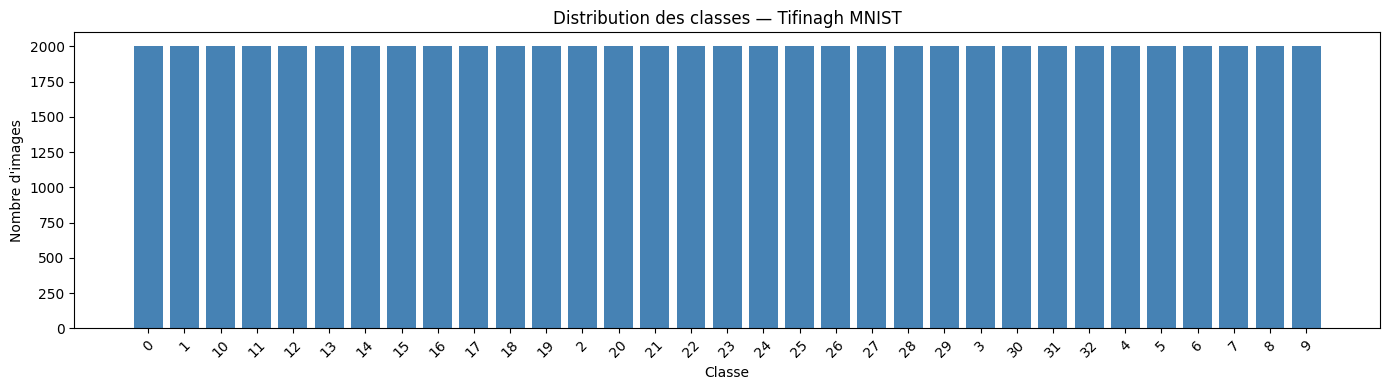

In [7]:
# ─── 3. DISTRIBUTION DES CLASSES ──────────────────────────
plt.figure(figsize=(14, 4))
counts = Counter(labels)
plt.bar([class_names[i] for i in counts.keys()], counts.values(), color="steelblue")
plt.title("Distribution des classes — Tifinagh MNIST")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/figures/distribution_classes.png")
plt.show()


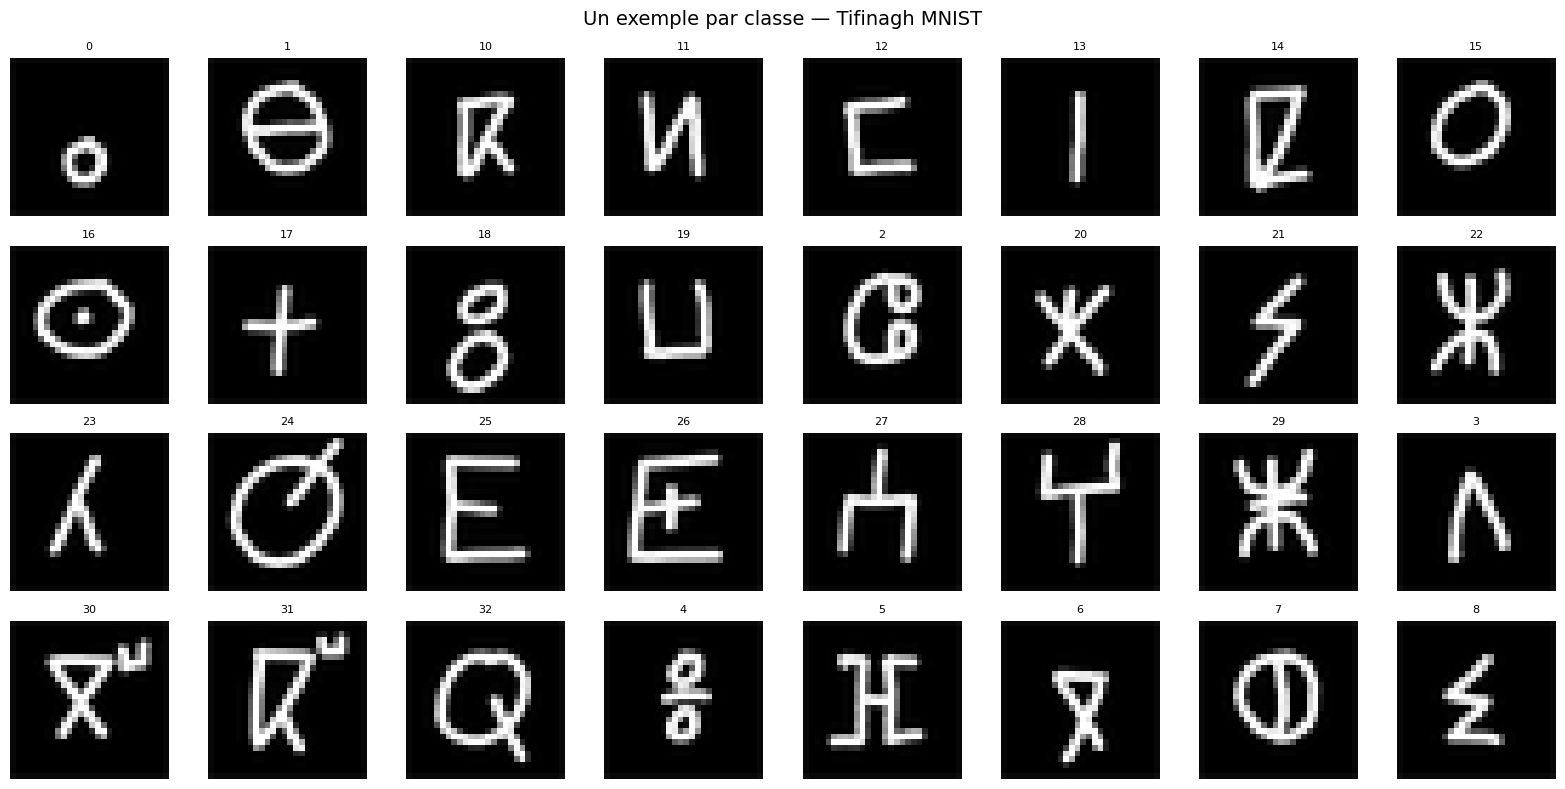

In [8]:
# ─── 4. VISUALISATION D'EXEMPLES ──────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

shown = {}
idx = 0
for i, (img, label) in enumerate(zip(images, labels)):
    if label not in shown and idx < 32:
        axes[idx].imshow(img, cmap="gray")
        axes[idx].set_title(class_names[label], fontsize=8)
        axes[idx].axis("off")
        shown[label] = True
        idx += 1

plt.suptitle("Un exemple par classe — Tifinagh MNIST", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/exemples_classes.png")
plt.show()

In [9]:
# ─── 5. STATISTIQUES BASIQUES ─────────────────────────────
print(f"\nPixel min  : {images.min()}")
print(f"Pixel max  : {images.max()}")
print(f"Pixel mean : {images.mean():.2f}")
print(f"Dataset équilibré ? {'Oui' if max(counts.values()) - min(counts.values()) < 50 else 'Non, à vérifier'}")


Pixel min  : 0
Pixel max  : 255
Pixel mean : 26.59
Dataset équilibré ? Oui
